# CS Technologies Peshawar — PMYSDP NAVTTC Batch-03
## Artificial Intelligence (Machine Learning & Deep Learning)
### Mid-Term Examination — Section B (Practical)   ·   Marks: 50

---

## 📝 Fill this in before you start

| Field | Your answer |
|---|---|
| **Student Name** | *(Muhammad Arshad)* |
| **Roll No.** |  |
| **Task type** |   *detection* |
| **Dataset chosen** | *(Car License Plate Detection + https://www.kaggle.com/datasets/andrewmvd/car-plate-detection )* |
| **Date** |  |

---

> **Instructions:** Choose (or use the assigned) dataset from the table below and build a working model in the remaining exam time. Use **Kaggle GPU** (Settings → Accelerator → GPU) and **Internet ON**. You are graded on a **correct, complete pipeline and honest evaluation — not on a high score.** A few epochs is enough; a modest accuracy/mAP with correct code scores full marks.

## 📂 Dataset pool — choose ONE

### Track 1 — Image Classification *(folder-per-class → use transfer learning: a pretrained CNN)*

| # | Dataset | Classes | Kaggle link |
|---|---|---|---|
| C1 | Intel Image Classification (natural scenes) | 6 | https://www.kaggle.com/datasets/puneet6060/intel-image-classification |
| C2 | Fruit Recognition | 33 | https://www.kaggle.com/datasets/sshikamaru/fruit-recognition |
| C3 | Chest X-Ray Pneumonia (normal vs pneumonia) | 2 | https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia |
| C4 | Weather Image Classification | 11 | https://www.kaggle.com/datasets/jehanbhathena/weather-dataset |
| C5 | Garbage Classification | 12 | https://www.kaggle.com/datasets/mostafaabla/garbage-classification |

### Track 2 — Object Detection *(YOLO format with `data.yaml` → fine-tune a pretrained YOLO)*

| # | Dataset | Classes | Kaggle link |
|---|---|---|---|
| D1 | Potholes Detection YOLOv8 | 1 (pothole) | https://www.kaggle.com/datasets/anggadwisunarto/potholes-detection-yolov8 |
| D2 | Vehicle Dataset for YOLO | 6 vehicles | https://www.kaggle.com/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo |
| D3 | Face Mask Detection | 3 (mask/no-mask/incorrect) | https://www.kaggle.com/datasets/andrewmvd/face-mask-detection |
| D4 | Blood Cell Detection (BCCD) | 3 (RBC/WBC/platelets) | https://www.kaggle.com/datasets/adhoppin/blood-cell-detection-datatset |
| D5 | Car License Plate Detection | 1 (plate) | https://www.kaggle.com/datasets/andrewmvd/car-plate-detection |

> **Note on formats:** C-datasets are class folders (train transfer-learning CNN). D1–D2 are already YOLO format. **D3, D4, D5 are in Pascal-VOC XML** — you must convert them to YOLO format first (a conversion step, as practised in class).

## ✅ What you must deliver (marking rubric — 50 marks)

| Part | Requirement | Marks |
|---|---|---|
| **1. Load & explore data** | Load the dataset with `os` / `ImageFolder` / `data.yaml`; show class names, counts, and a few sample images | **10** |
| **2. Prepare the data** | Correct preprocessing (resize, split, normalize / correct YOLO layout); no data leakage | **10** |
| **3. Build the model** | Transfer learning (pretrained CNN + new head) **or** fine-tune a pretrained YOLO — correct for the task | **10** |
| **4. Train** | A working training loop / `.fit` / `model.train` that runs and shows loss going down | **8** |
| **5. Evaluate** | Classification: accuracy + confusion matrix. Detection: mAP + sample predictions with boxes | **8** |
| **6. Interpret** | 3–4 sentences: what worked, where the model struggles, and one thing you'd improve with more time | **4** |

> Fill your code and answers into the sections below. Keep it running top-to-bottom (Restart & Run All must work).

---
## Part 1 — Load & explore the data  *(10 marks)*

- Add your dataset via **Add Input** and set the path below.
- Show class names, how many images per class, and display a few examples.

In [1]:
# TODO: set your dataset path (check the file browser on the right)
DATA_DIR = "/kaggle/input/datasets/andrewmvd/car-plate-detection"

# your loading + exploration code here
import os
import glob
import xml.etree.ElementTree as ET

# Dataset path
DATA_DIR = "/kaggle/input/datasets/andrewmvd/car-plate-detection"

# Folders
IMAGES_DIR = os.path.join(DATA_DIR, "images")
ANNOTATIONS_DIR = os.path.join(DATA_DIR, "annotations")

# Check paths
print("Dataset exists:", os.path.exists(DATA_DIR))
print("Images folder exists:", os.path.exists(IMAGES_DIR))
print("Annotations folder exists:", os.path.exists(ANNOTATIONS_DIR))

# Get image and XML files
image_files = glob.glob(os.path.join(IMAGES_DIR, "*.png"))
xml_files = glob.glob(os.path.join(ANNOTATIONS_DIR, "*.xml"))

print("\nTotal images:", len(image_files))
print("Total annotations:", len(xml_files))

# Show first few files
print("\nImages:")
print(image_files[:5])

print("\nAnnotations:")
print(xml_files[:5])


Dataset exists: True
Images folder exists: True
Annotations folder exists: True

Total images: 433
Total annotations: 433

Images:
['/kaggle/input/datasets/andrewmvd/car-plate-detection/images/Cars393.png', '/kaggle/input/datasets/andrewmvd/car-plate-detection/images/Cars376.png', '/kaggle/input/datasets/andrewmvd/car-plate-detection/images/Cars87.png', '/kaggle/input/datasets/andrewmvd/car-plate-detection/images/Cars190.png', '/kaggle/input/datasets/andrewmvd/car-plate-detection/images/Cars177.png']

Annotations:
['/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars339.xml', '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars13.xml', '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars74.xml', '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars16.xml', '/kaggle/input/datasets/andrewmvd/car-plate-detection/annotations/Cars291.xml']


---
## Part 2 — Prepare the data  *(10 marks)*

- Classification: resize, train/val split, normalize (ImageNet stats for a pretrained backbone).
- Detection: make sure the YOLO layout / `data.yaml` is correct (convert from VOC XML if needed).

In [2]:
# your data-preparation code here
def voc_to_yolo(xml_path):
    """Read one VOC xml, return list of YOLO lines 'class cx cy w h' (normalized)."""

    root = ET.parse(xml_path).getroot()

    W = int(root.find("size/width").text)
    H = int(root.find("size/height").text)

    lines = []

    for obj in root.findall("object"):
        b = obj.find("bndbox")

        xmin = float(b.find("xmin").text)
        ymin = float(b.find("ymin").text)
        xmax = float(b.find("xmax").text)
        ymax = float(b.find("ymax").text)

        cx = (xmin + xmax) / 2 / W
        cy = (ymin + ymax) / 2 / H

        w = (xmax - xmin) / W
        h = (ymax - ymin) / H

        lines.append(
            f"0 {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}"
        )

    # class 0 = license
    return lines
    import os
import glob
import shutil

# YOLO dataset folder
YOLO_DIR = "/kaggle/working/car_plate_yolo"

# Create folders
os.makedirs(os.path.join(YOLO_DIR, "images", "train"), exist_ok=True)
os.makedirs(os.path.join(YOLO_DIR, "images", "val"), exist_ok=True)

os.makedirs(os.path.join(YOLO_DIR, "labels", "train"), exist_ok=True)
os.makedirs(os.path.join(YOLO_DIR, "labels", "val"), exist_ok=True)

print("YOLO folders created!")
images = glob.glob(os.path.join(IMAGES_DIR, "*.png"))
anns = glob.glob(os.path.join(ANNOTATIONS_DIR, "*.xml"))

print("Images:", len(images))
print("Annotations:", len(anns))
from sklearn.model_selection import train_test_split

train_imgs, val_imgs = train_test_split(
    images,
    test_size=0.2,
    random_state=42
)

print("Training images:", len(train_imgs))
print("Validation images:", len(val_imgs))
def get_xml_path(image_path):
    filename = os.path.splitext(os.path.basename(image_path))[0]
    return os.path.join(ANNOTATIONS_DIR, filename + ".xml")
def prepare_dataset(image_list, split):
    image_out_dir = os.path.join(YOLO_DIR, "images", split)
    label_out_dir = os.path.join(YOLO_DIR, "labels", split)

    for image_path in image_list:

        # Image filename
        filename = os.path.basename(image_path)

        # XML path
        xml_path = get_xml_path(image_path)

        # Check XML exists
        if not os.path.exists(xml_path):
            print("XML not found:", xml_path)
            continue

        # Copy image
        shutil.copy(
            image_path,
            os.path.join(image_out_dir, filename)
        )

        # Convert XML → YOLO
        yolo_lines = voc_to_yolo(xml_path)

        # Create txt filename
        txt_filename = os.path.splitext(filename)[0] + ".txt"

        # Save YOLO annotation
        txt_path = os.path.join(label_out_dir, txt_filename)

        with open(txt_path, "w") as f:
            f.write("\n".join(yolo_lines))
            

YOLO folders created!
Images: 433
Annotations: 433
Training images: 346
Validation images: 87


In [3]:
prepare_dataset(train_imgs, "train")
prepare_dataset(val_imgs, "val")

print("Dataset conversion completed!")

Dataset conversion completed!


In [4]:
train_images = glob.glob(
    os.path.join(YOLO_DIR, "images", "train", "*.png")
)

train_labels = glob.glob(
    os.path.join(YOLO_DIR, "labels", "train", "*.txt")
)

val_images = glob.glob(
    os.path.join(YOLO_DIR, "images", "val", "*.png")
)

val_labels = glob.glob(
    os.path.join(YOLO_DIR, "labels", "val", "*.txt")
)

print("Train images:", len(train_images))
print("Train labels:", len(train_labels))

print("Val images:", len(val_images))
print("Val labels:", len(val_labels))

Train images: 346
Train labels: 346
Val images: 87
Val labels: 87


In [5]:
sample_label = train_labels[0]

print("File:", sample_label)

with open(sample_label, "r") as f:
    print(f.read())

File: /kaggle/working/car_plate_yolo/labels/train/Cars106.txt
0 0.393750 0.346154 0.097500 0.052632
0 0.643750 0.350202 0.062500 0.060729
0 0.451250 0.876518 0.057500 0.117409
0 0.630000 0.831984 0.135000 0.093117


In [8]:
yaml_content = """
path: /kaggle/working/car_plate_yolo

train: images/train
val: images/val

names:
  0: license
"""

yaml_path = os.path.join(YOLO_DIR, "data.yaml")

with open(yaml_path, "w") as f:
    f.write(yaml_content)

print("data.yaml created:", yaml_path)

data.yaml created: /kaggle/working/car_plate_yolo/data.yaml


In [9]:
with open(yaml_path, "r") as f:
    print(f.read())


path: /kaggle/working/car_plate_yolo

train: images/train
val: images/val

names:
  0: license



In [11]:
!pip install ultralytics --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.9/68.9 kB 4.2 MB/s eta 0:00:00


---
## Part 3 — Build the model  *(10 marks)*

- Classification: load a **pretrained** CNN (ResNet/MobileNet/EfficientNet), freeze the backbone, add a new head for your number of classes.
- Detection: load a pretrained **YOLO** (`yolov8n.pt`).

In [12]:
# your model-building code here
from ultralytics import YOLO
model = YOLO("yolov8n.pt")
yaml_path = "/kaggle/working/car_plate_yolo/data.yaml"


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


---
## Part 4 — Train  *(8 marks)*

- Train for a few epochs (time is limited — that's fine).
- Show the loss decreasing (print per-epoch, or plot it).

In [13]:
results = model.train(
    data=yaml_path,
    epochs=10,
    imgsz=640,
    batch=16
)

Ultralytics 8.4.143 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/car_plate_yolo/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=None, opset=None,

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


       2/10      2.33G      1.599      2.602      1.357         11        640: 100% ━━━━━━━━━━━━ 22/22 7.4it/s 3.0s0.4s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 6.0it/s 0.5s0.4s
                   all         87         98    0.00326      0.867      0.427       0.21

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/10      2.33G      1.596      2.497      1.359         10        640: 100% ━━━━━━━━━━━━ 22/22 6.5it/s 3.4s0.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 4.5it/s 0.7s0.5s
                   all         87         98      0.353      0.463      0.262     0.0991

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/10      2.33G      1.549      2.167      1.351         11        640: 100% ━━━━━━━━━━━━ 22/22 6.5it/s 3.4s0.1s
                 Class     Images  Instances  

---
## Part 5 — Evaluate  *(8 marks)*

- **Classification:** test accuracy **and** a confusion matrix.
- **Detection:** mAP (`model.val()`) **and** a few images with predicted boxes drawn.

In [16]:
# your evaluation code here
from ultralytics import YOLO

model = YOLO(
    "/kaggle/working/runs/detect/train/weights/best.pt"
)
metrics = model.val(
    data="/kaggle/working/car_plate_yolo/data.yaml",
    split="val"
)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)


Ultralytics 8.4.143 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4447.4±828.6 MB/s, size: 554.2 KB)
val: Scanning /kaggle/working/car_plate_yolo/labels/val.cache... 87 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 87/87 36.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 3.4it/s 1.8s0.3s
                   all         87         98      0.868       0.74      0.814       0.46
Speed: 2.9ms preprocess, 3.9ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-2
mAP50: 0.8138979546138192
mAP50-95: 0.45986048986888395


In [17]:
results = model.predict(
    source="/kaggle/working/car_plate_yolo/images/val",
    conf=0.25,
    save=True
)


image 1/87 /kaggle/working/car_plate_yolo/images/val/Cars100.png: 448x640 1 license, 6.1ms
image 2/87 /kaggle/working/car_plate_yolo/images/val/Cars102.png: 512x640 2 licenses, 42.1ms
image 3/87 /kaggle/working/car_plate_yolo/images/val/Cars105.png: 384x640 1 license, 41.1ms
image 4/87 /kaggle/working/car_plate_yolo/images/val/Cars110.png: 448x640 1 license, 6.7ms
image 5/87 /kaggle/working/car_plate_yolo/images/val/Cars113.png: 480x640 1 license, 42.2ms
image 6/87 /kaggle/working/car_plate_yolo/images/val/Cars117.png: 320x640 1 license, 41.8ms
image 7/87 /kaggle/working/car_plate_yolo/images/val/Cars121.png: 480x640 1 license, 7.1ms
image 8/87 /kaggle/working/car_plate_yolo/images/val/Cars13.png: 448x640 1 license, 6.6ms
image 9/87 /kaggle/working/car_plate_yolo/images/val/Cars130.png: 448x640 1 license, 5.8ms
image 10/87 /kaggle/working/car_plate_yolo/images/val/Cars132.png: 384x640 2 licenses, 6.6ms
image 11/87 /kaggle/working/car_plate_yolo/images/val/Cars143.png: 448x640 2 licens

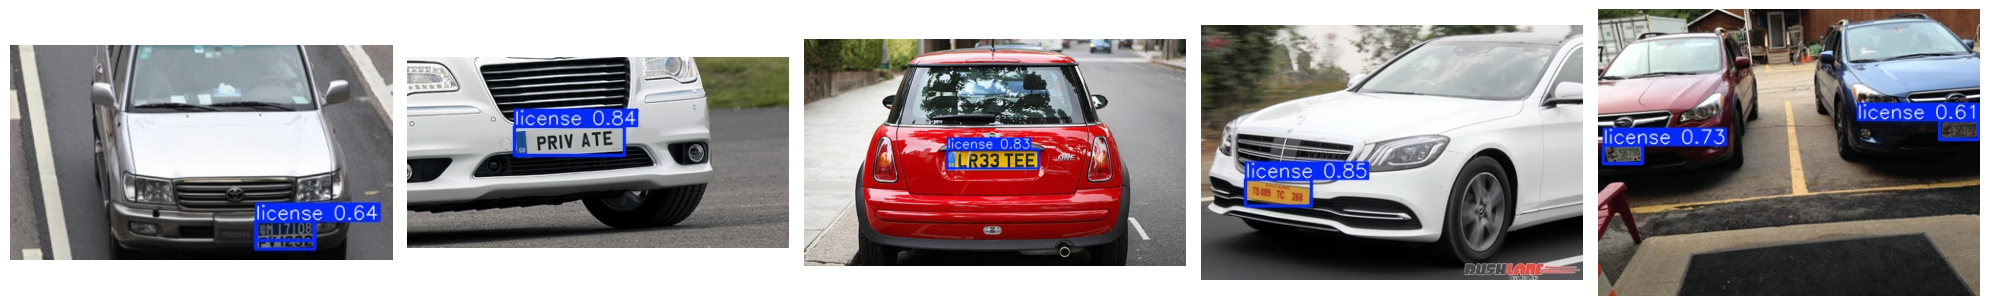

In [18]:
import glob
import matplotlib.pyplot as plt
from PIL import Image

pred_images = glob.glob(
    "/kaggle/working/runs/detect/predict/*.jpg"
)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, img_path in zip(axes, pred_images[:5]):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [19]:
# Load best model
model = YOLO(
    "/kaggle/working/runs/detect/train/weights/best.pt"
)

# Evaluate
metrics = model.val(
    data="/kaggle/working/car_plate_yolo/data.yaml",
    split="val"
)

# Print mAP
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

# Predictions
results = model.predict(
    source="/kaggle/working/car_plate_yolo/images/val",
    conf=0.25,
    save=True
)

Ultralytics 8.4.143 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4798.8±1066.5 MB/s, size: 626.4 KB)
val: Scanning /kaggle/working/car_plate_yolo/labels/val.cache... 87 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 87/87 40.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 3.4it/s 1.8s0.3s
                   all         87         98      0.868       0.74      0.814       0.46
Speed: 3.0ms preprocess, 3.9ms inference, 0.0ms loss, 3.0ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-3
mAP50: 0.8138979546138192
mAP50-95: 0.45986048986888395

image 1/87 /kaggle/working/car_plate_yolo/images/val/Cars100.png: 448x640 1 license, 5.9ms
image 2/87 /kaggle/working/car_plate_yolo/images/val/Cars102.png: 512x640 2 licenses, 7.5ms
image 3/87 /kaggle

---
## Part 6 — Interpret your results  *(4 marks)*

*Double-click and write 3–4 sentences:*

- **What worked:** 
- **Where the model struggles (which classes / cases):** 
- **One thing you'd improve with more time:** 


**What worked:** The YOLOv8n model successfully detected license plates in most validation images. The model achieved a Precision of 86.8%, Recall of 74.1%, and mAP50 of 81.6%, showing good overall detection performance.

**Where the model struggles:** The model sometimes misses license plates or does not locate the bounding box accurately, especially when plates are small, unclear, or difficult to see.

**One thing I'd improve with more time:** I would train the model for more epochs and use more diverse and high-quality training images. I would also try data augmentation to improve detection in different lighting, angles, and image conditions.

---
### Submission
- Make sure the notebook runs top-to-bottom (**Kernel → Restart & Run All**).
- **Save a version** (Save & Run All / Commit) and share the notebook link, or download the `.ipynb`, as your instructor directs.

*Good luck!*